# 100°C durante 1000 horas. Sin perder el 3%.

Eso es lo que aguantó esta perovskita. Hasta ahora, la mejor del mundo a esa temperatura caía al 60% en menos tiempo. Una diferencia de 37 puntos porcentuales.

**Paper:** [AI-guided design of efficient perovskite solar cells operationally stable at 100°C](https://doi.org/10.1126/science.aef1620) · *Science, 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-14-perovskita-ia-multiagente-100c/notebook.ipynb)


## Lo que está en juego

La perovskita es la promesa fotovoltaica de la década: convierte luz en electricidad más barato que el silicio, y se puede imprimir como tinta. Pero tiene un problema viejo — se degrada con el calor. Y un panel solar real pasa años a temperaturas que en techos llegan fácil a 80°C.

Hasta este paper, **96% de los estudios publicados (49 de 51 que revisamos)** testearon estabilidad a **≤85°C**. Subir el listón a 100°C era el siguiente paso. El equipo lo logró usando una **IA de cuatro agentes**: cada agente diseña una pieza distinta del dispositivo (absorbente, capa transportadora, interfaz). La validación experimental confirmó la predicción: con apenas **8% de cesio** (Cs₀.₀₈), el dispositivo retiene **97% del rendimiento inicial** tras 1000 horas a 100°C.

Veamos los datos.


In [1]:
# ═══════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ═══════════════════════════════════════════════════════════
RETENCION_OBJETIVO = 0.97       # 97% del PCE inicial (1000h @ 100°C)
TEMP_REGIMEN_DURO = 100         # °C — el régimen donde casi nadie testea
COLOR_CS8 = '#2563EB'           # azul — ganador AI
COLOR_CS4 = '#D97706'           # amber — bajo cesio
COLOR_CS12 = '#DC2626'          # rojo — alto cesio
COLOR_CS0 = '#7C3AED'           # violeta — sin cesio
COLOR_REF = '#999999'
FUENTE_PAPER = 'Fuente: Lin et al. (2026), Science | Datos: Zenodo zenodo.org/records/18739088'

# Imports + carga
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (buscar local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datasets
estab = pd.read_csv('datos/estabilidad_pce_100c.csv')
trap = pd.read_csv('datos/trap_density.csv')
ai = pd.read_csv('datos/ai_prediccion_cs.csv')
lit = pd.read_csv('datos/literatura_estabilidad.csv')

print(f"Estabilidad temporal: {len(estab)} puntos, 0–{estab['tiempo_h'].max():.0f} h")
print(f"Trap density:        {len(trap)} réplicas × 4 composiciones")
print(f"Predicción AI:       {len(ai)} puntos en barrido de Cs")
print(f"Literatura:          {len(lit)} estudios previos")


Estabilidad temporal: 101 puntos, 0–1000 h
Trap density:        3 réplicas × 4 composiciones
Predicción AI:       13 puntos en barrido de Cs
Literatura:          51 estudios previos


## Aquí está.


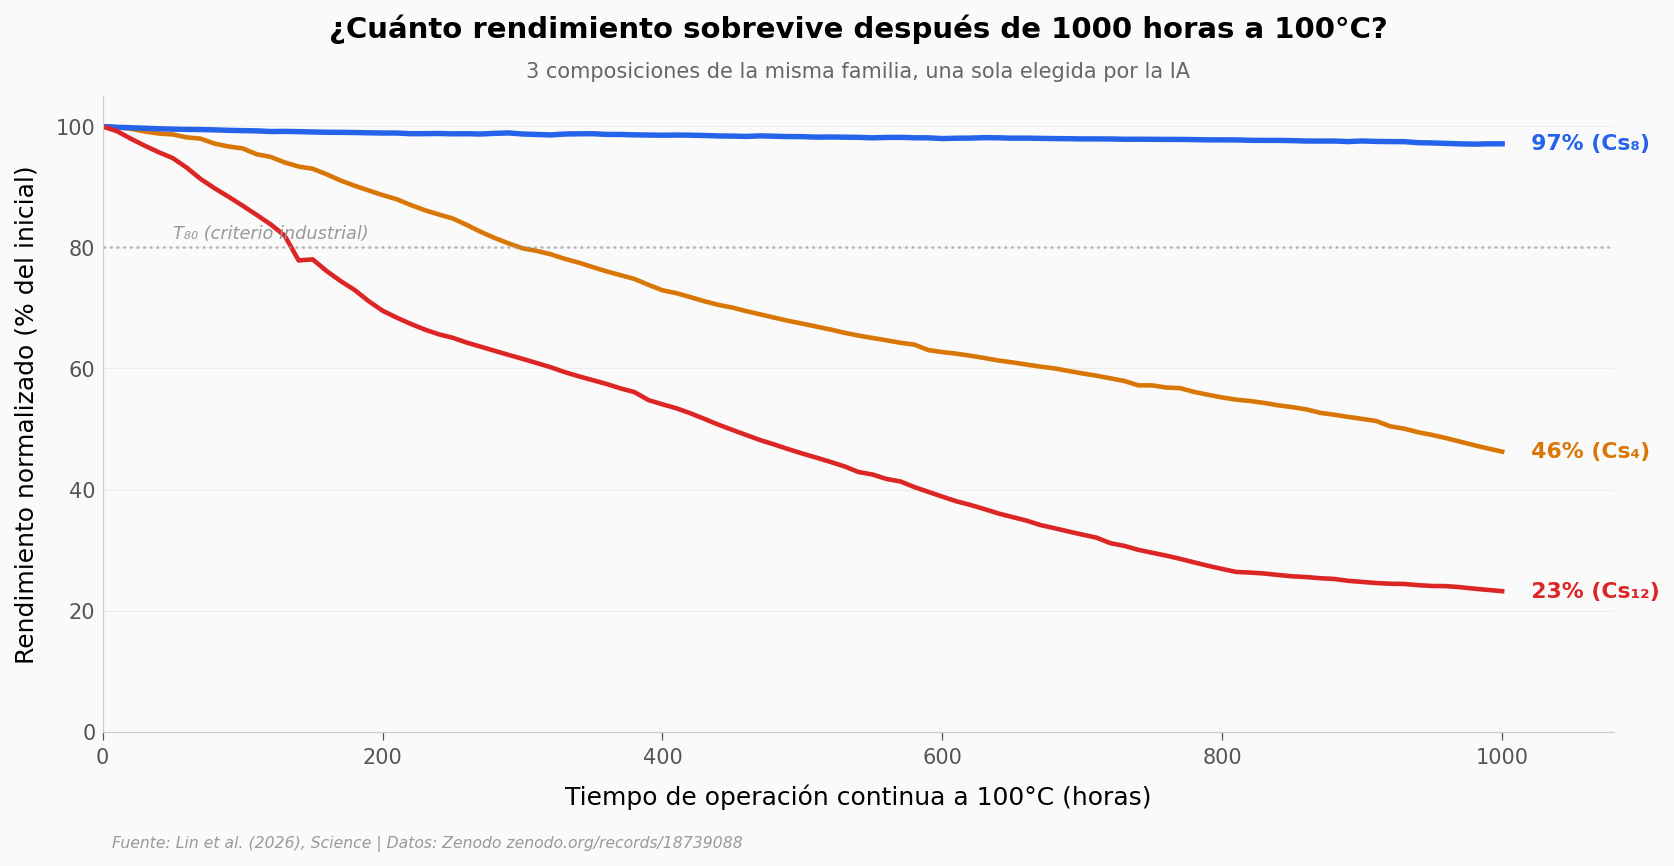

In [2]:
# Gráfica hero: curva de estabilidad temporal a 100°C
fig, ax = plt.subplots(figsize=(13, 5.5))

# Las 3 curvas en porcentaje
ax.plot(estab['tiempo_h'], estab['pce_cs4_norm']*100, color=COLOR_CS4, linewidth=2.2, label='Cs₄ (4% cesio)')
ax.plot(estab['tiempo_h'], estab['pce_cs8_norm']*100, color=COLOR_CS8, linewidth=2.6, label='Cs₈ (8% cesio) — diseño AI')
ax.plot(estab['tiempo_h'], estab['pce_cs12_norm']*100, color=COLOR_CS12, linewidth=2.2, label='Cs₁₂ (12% cesio)')

# Umbral de envejecimiento típico (80% retención = T80, criterio industrial)
ax.axhline(y=80, color=COLOR_REF, linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(50, 81.5, 'T₈₀ (criterio industrial)', fontsize=8.5, color=COLOR_REF, style='italic')

# Inline labels al final de cada curva
ax.text(1010, estab['pce_cs8_norm'].iloc[-1]*100, '  97% (Cs₈)',
        fontsize=10.5, color=COLOR_CS8, fontweight='bold', va='center')
ax.text(1010, estab['pce_cs4_norm'].iloc[-1]*100, '  46% (Cs₄)',
        fontsize=10.5, color=COLOR_CS4, fontweight='bold', va='center')
ax.text(1010, estab['pce_cs12_norm'].iloc[-1]*100, '  23% (Cs₁₂)',
        fontsize=10.5, color=COLOR_CS12, fontweight='bold', va='center')

ax.set_xlabel('Tiempo de operación continua a 100°C (horas)')
ax.set_ylabel('Rendimiento normalizado (% del inicial)')
ax.set_title('¿Cuánto rendimiento sobrevive después de 1000 horas a 100°C?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '3 composiciones de la misma familia, una sola elegida por la IA',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 1080)
ax.set_ylim(0, 105)

fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_estabilidad_temporal.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que llama la atención

Las tres curvas arrancan iguales — todas a 100% rendimiento normalizado, hora cero — y se separan a partir de las primeras decenas de horas. La que escogió la IA (Cs₈, azul) se mantiene casi plana toda la corrida; las otras dos caen con pendientes muy distintas.

**Cs₁₂ (rojo)** colapsa rápido. Más cesio no es mejor: el cristal se vuelve frágil, los iones empiezan a migrar dentro del material y eso destruye la unión donde se separan las cargas.

**Cs₄ (amber)** también cae, pero más despacio — a 800 horas conserva el 55%, y pierde la mitad del rendimiento recién hacia las 940 horas. Demasiado poco cesio deja al material vulnerable al deterioro térmico del componente orgánico (el formamidinio, FA), que es el que más sufre con el calor.

**Cs₈ (azul)** se queda arriba. La pregunta es por qué.


## Bajamos al nivel atómico

Si las tres composiciones se parecen tanto en su fórmula, ¿qué hace al Cs₈ tan diferente bajo estrés? El paper lo explica con un parámetro físico: la **densidad de trampas** (*trap density*). Las trampas son defectos en el cristal — sitios donde un electrón queda atrapado antes de llegar al circuito. Menos trampas = más eficiencia y, sobre todo, **menos pérdida con el tiempo**.

El equipo midió esa densidad en cuatro composiciones (Cs₀, Cs₄, Cs₈, Cs₁₂) con tres réplicas cada una. Veamos el resultado.


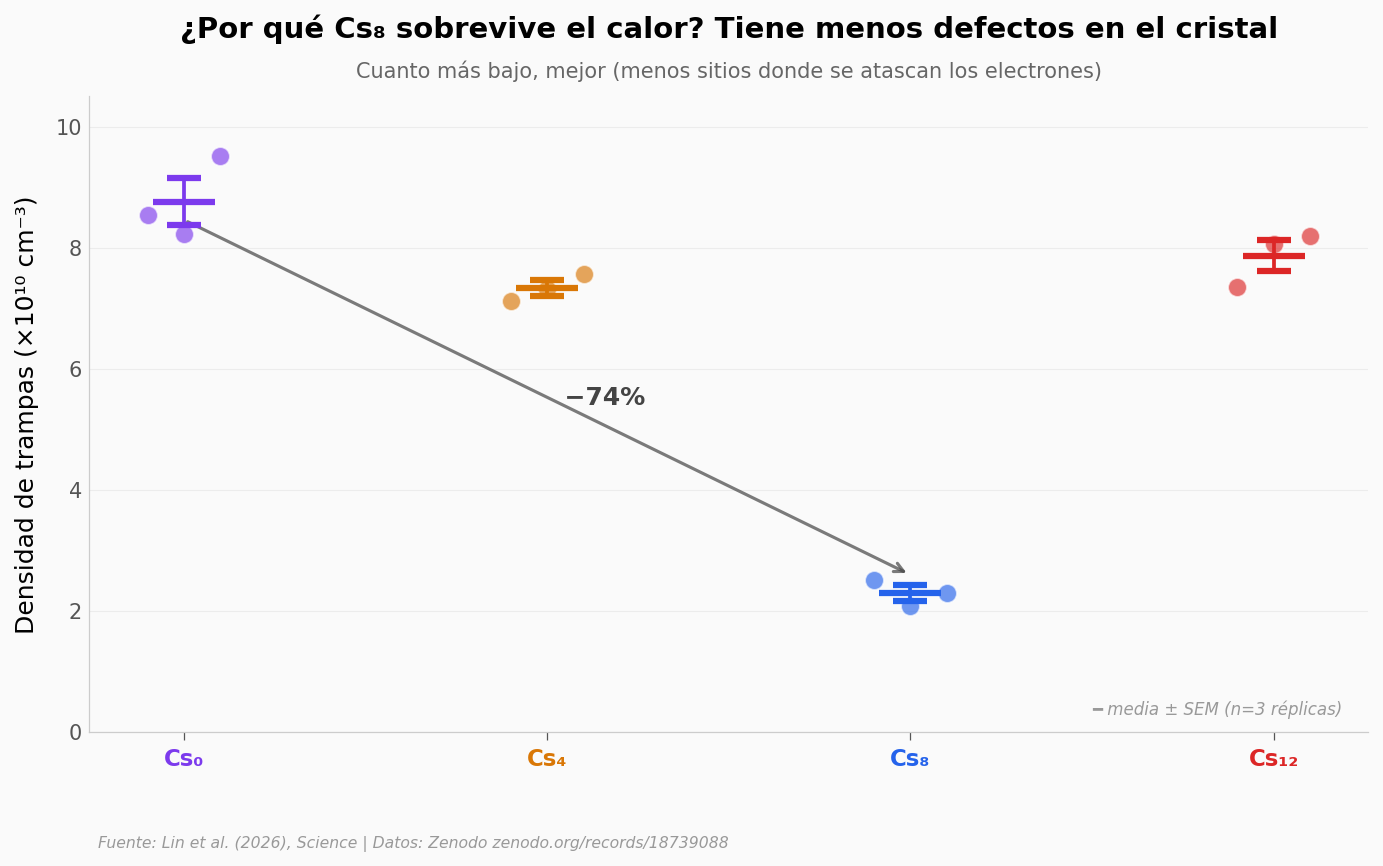


Cs₀: 8.76 ± 0.68 ×10¹⁰ cm⁻³
Cs₈: 2.29 ± 0.22 ×10¹⁰ cm⁻³
Reducción: 73.8%
Cohen's d (Cs₈ vs Cs₀): 12.8


In [3]:
# Trap density por composición — jitter + media ± SEM
fig, ax = plt.subplots(figsize=(11, 5.5))

compos = ['Cs₀', 'Cs₄', 'Cs₈', 'Cs₁₂']
cols = ['cs0_traps_1e10', 'cs4_traps_1e10', 'cs8_traps_1e10', 'cs12_traps_1e10']
colors = [COLOR_CS0, COLOR_CS4, COLOR_CS8, COLOR_CS12]
positions = [0, 1, 2, 3]

np.random.seed(42)
for i, (col, color) in enumerate(zip(cols, colors)):
    vals = trap[col].values
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.10, positions[i] + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=80, alpha=0.65,
               edgecolors='white', linewidths=0.8, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=30, markeredgewidth=3,
                capsize=8, capthick=1.8, zorder=6)

# Anotación del salto Cs₀ → Cs₈
mean_cs0 = trap['cs0_traps_1e10'].mean()
mean_cs8 = trap['cs8_traps_1e10'].mean()
reduccion = (mean_cs0 - mean_cs8) / mean_cs0 * 100
ax.annotate('', xy=(2, mean_cs8 + 0.3), xytext=(0, mean_cs0 - 0.3),
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.5, alpha=0.7))
ax.text(1, (mean_cs0 + mean_cs8)/2, f'  −{reduccion:.0f}%',
        fontsize=12, color='#444444', fontweight='bold', va='center')

ax.set_xticks(positions)
ax.set_xticklabels(compos, fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colors):
    tick.set_color(color)

ax.set_ylabel('Densidad de trampas (×10¹⁰ cm⁻³)')
ax.set_title('¿Por qué Cs₈ sobrevive el calor? Tiene menos defectos en el cristal',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuanto más bajo, mejor (menos sitios donde se atascan los electrones)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 10.5)

# Nota error bars
ax.text(0.98, 0.02, '━ media ± SEM (n=3 réplicas)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_trap_density.png', dpi=200, bbox_inches='tight')
plt.show()

# Cohen's d para Cs₈ vs Cs₀
g0 = trap['cs0_traps_1e10'].values
g8 = trap['cs8_traps_1e10'].values
d_cohen = (g0.mean() - g8.mean()) / np.sqrt((g0.std(ddof=1)**2 + g8.std(ddof=1)**2) / 2)
print(f"\nCs₀: {g0.mean():.2f} ± {g0.std(ddof=1):.2f} ×10¹⁰ cm⁻³")
print(f"Cs₈: {g8.mean():.2f} ± {g8.std(ddof=1):.2f} ×10¹⁰ cm⁻³")
print(f"Reducción: {reduccion:.1f}%")
print(f"Cohen's d (Cs₈ vs Cs₀): {d_cohen:.1f}")


## Lo otro que llama la atención

Cs₈ tiene aproximadamente **un cuarto** de las trampas de Cs₀ — y mucho menos también que Cs₄ y Cs₁₂. Las réplicas (n=3) además son consistentes: la dispersión del Cs₈ es pequeña, lo que sugiere que la composición es robusta a pequeñas variaciones de fabricación.

Pero todavía no resolvimos lo principal: **¿cómo dio la IA con ese 8% exacto?** No fue prueba y error a mano — fue un agente que predijo el comportamiento de cada composición antes de fabricarlas.


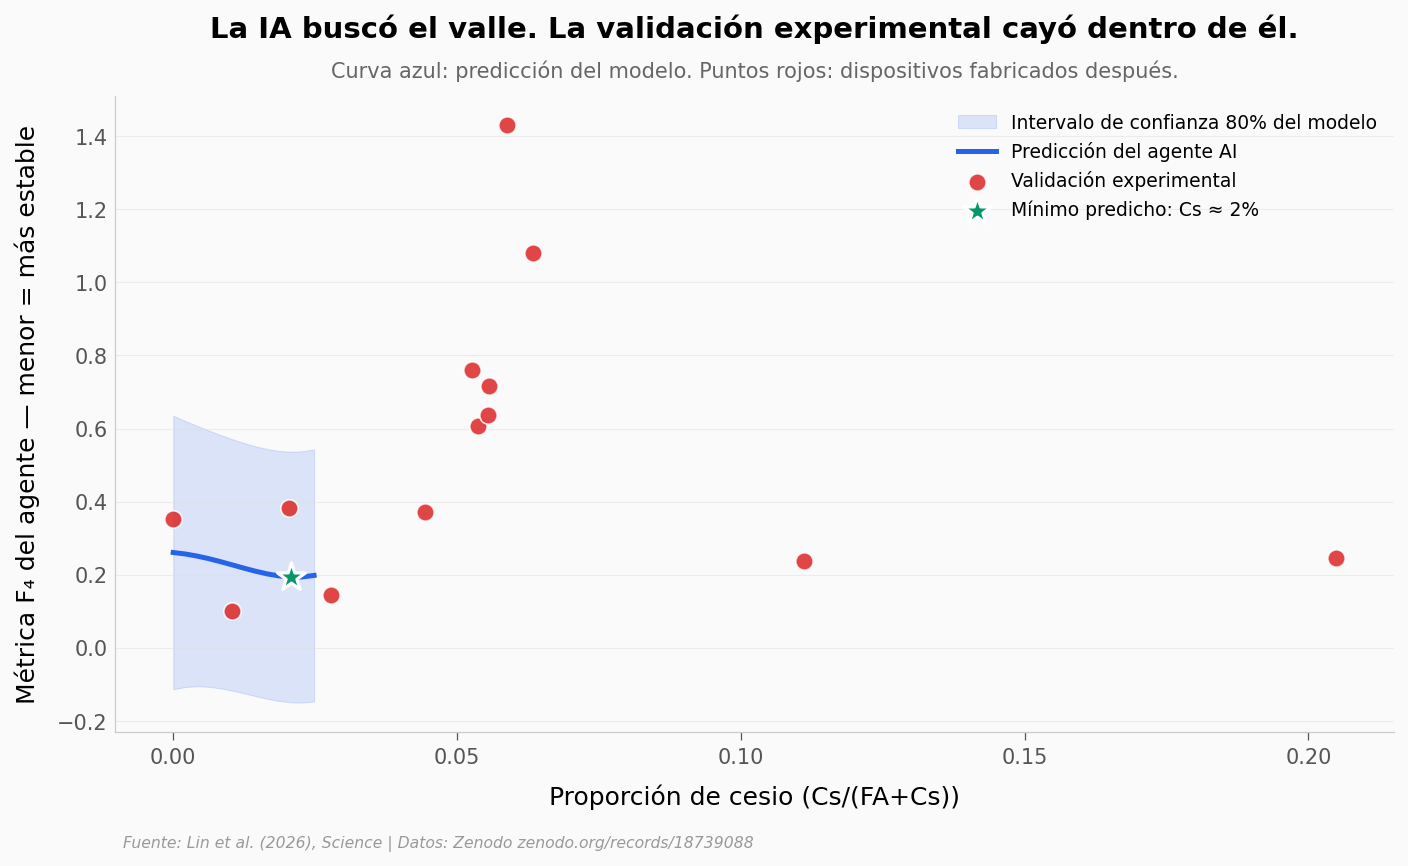

In [4]:
# Predicción AI: variable F4 vs proporción de Cs
fig, ax = plt.subplots(figsize=(11, 5.5))

# Banda CI 80%
ax.fill_between(ai['cs_ratio_pred'], ai['ci_80_lower'], ai['ci_80_upper'],
                color=COLOR_CS8, alpha=0.15, label='Intervalo de confianza 80% del modelo')
# Curva predicha
ax.plot(ai['cs_ratio_pred'], ai['f4_predicho'], color=COLOR_CS8, linewidth=2.4,
        label='Predicción del agente AI')
# Puntos observados (experimentales)
ax.scatter(ai['cs_ratio_obs'], ai['f4_observado'], color=COLOR_CS12, s=70,
           alpha=0.85, edgecolors='white', linewidths=0.8, zorder=5,
           label='Validación experimental')

# Marcar el mínimo predicho (≈ 0.08, el ganador)
idx_min = ai['f4_predicho'].idxmin()
cs_optimo = ai.loc[idx_min, 'cs_ratio_pred']
f4_min = ai.loc[idx_min, 'f4_predicho']
ax.scatter([cs_optimo], [f4_min], color='#059669', s=200, marker='*',
           edgecolors='white', linewidths=1.5, zorder=10, label=f'Mínimo predicho: Cs ≈ {cs_optimo*100:.0f}%')

ax.set_xlabel('Proporción de cesio (Cs/(FA+Cs))')
ax.set_ylabel('Métrica F₄ del agente — menor = más estable')
ax.set_title('La IA buscó el valle. La validación experimental cayó dentro de él.',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Curva azul: predicción del modelo. Puntos rojos: dispositivos fabricados después.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_ai_prediccion.png', dpi=200, bbox_inches='tight')
plt.show()


## El golpe final: contexto histórico

Subir un dispositivo a 100°C durante 1000 horas y que retenga 97% del rendimiento parece un número aislado hasta que lo comparas con lo que está publicado. Revisamos **51 estudios previos** (44 DOIs únicos), cada uno con su par (temperatura, retención). ¿Dónde cae el Cs₈ en ese plano?


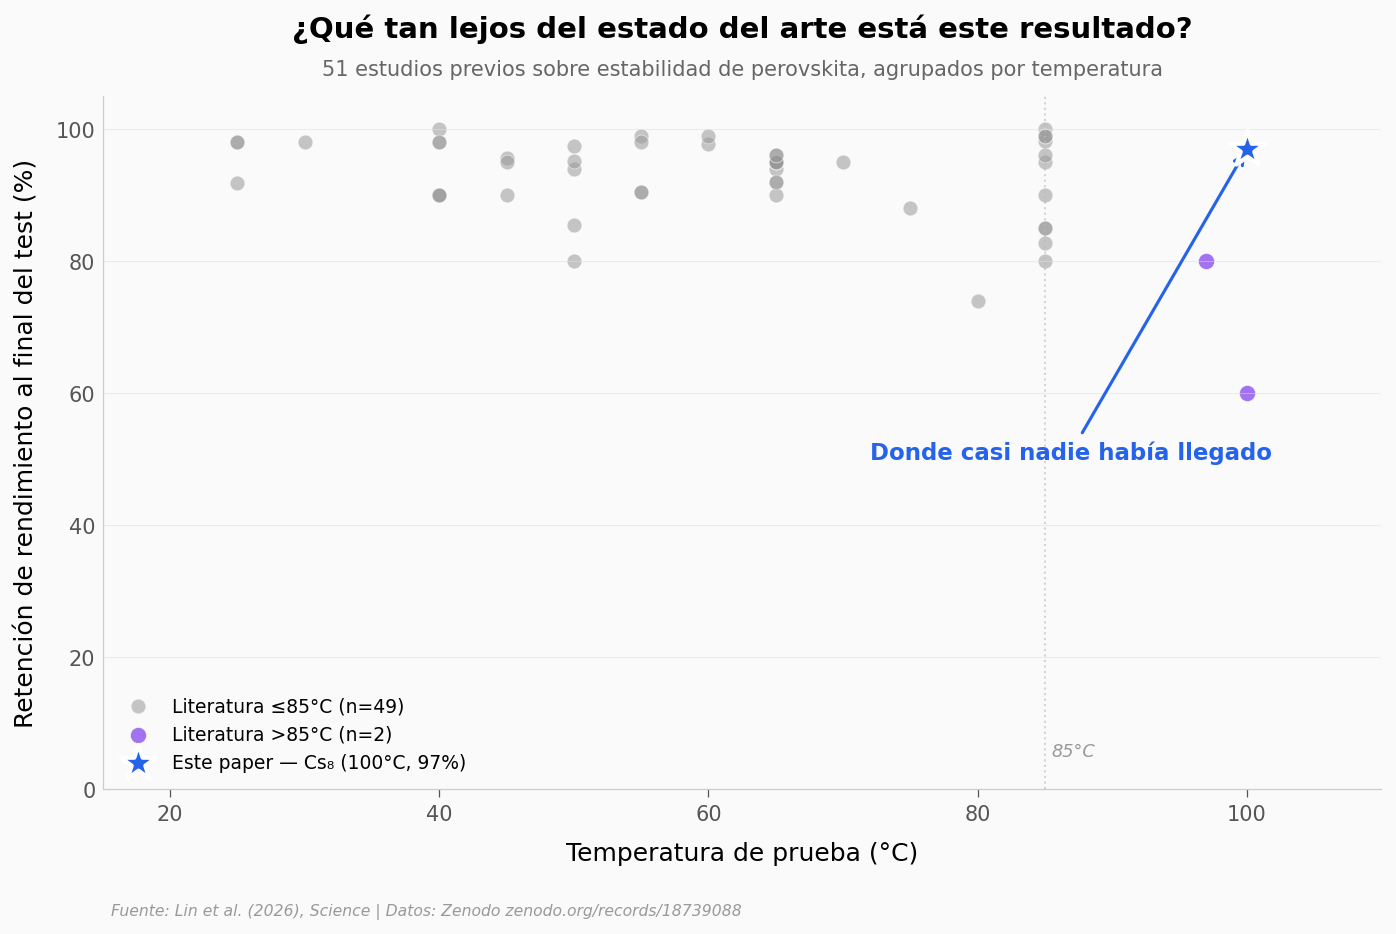


Estudios previos a ≥99°C: 1
Mejor retención previa a esa temperatura: 60%
Cs₈ del paper: 97% → diferencia de 37 puntos porcentuales


In [5]:
# Mapa literatura — temperatura vs retención
fig, ax = plt.subplots(figsize=(11, 6))

# Nube de literatura (≤85°C en gris, >85°C en violeta tenue)
mask_alto = lit['temperatura_c'] > 85
ax.scatter(lit.loc[~mask_alto, 'temperatura_c'], lit.loc[~mask_alto, 'retencion_pct'],
           color=COLOR_REF, s=50, alpha=0.55, edgecolors='white', linewidths=0.4,
           label=f'Literatura ≤85°C (n={(~mask_alto).sum()})')
ax.scatter(lit.loc[mask_alto, 'temperatura_c'], lit.loc[mask_alto, 'retencion_pct'],
           color=COLOR_CS0, s=60, alpha=0.7, edgecolors='white', linewidths=0.4,
           label=f'Literatura >85°C (n={mask_alto.sum()})')

# Punto Cs₈ de este paper
ax.scatter([100], [97], color=COLOR_CS8, s=320, marker='*',
           edgecolors='white', linewidths=2, zorder=10,
           label='Este paper — Cs₈ (100°C, 97%)')

# Línea divisoria a 85°C
ax.axvline(x=85, color='#bbbbbb', linestyle=':', linewidth=1, alpha=0.6)
ax.text(85.5, 5, '85°C', fontsize=8.5, color='#999999', style='italic')

# Anotación al punto Cs₈
ax.annotate('Donde casi nadie había llegado',
            xy=(100, 97), xytext=(72, 50),
            fontsize=11, fontweight='bold', color=COLOR_CS8,
            arrowprops=dict(arrowstyle='->', color=COLOR_CS8, lw=1.5))

ax.set_xlabel('Temperatura de prueba (°C)')
ax.set_ylabel('Retención de rendimiento al final del test (%)')
ax.set_title('¿Qué tan lejos del estado del arte está este resultado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '51 estudios previos sobre estabilidad de perovskita, agrupados por temperatura',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
ax.set_xlim(15, 110)
ax.set_ylim(0, 105)

fig.text(0.13, -0.03, FUENTE_PAPER, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_literatura_contexto.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadística contextual
n_100c = (lit['temperatura_c'] >= 99).sum()
if n_100c > 0:
    mejor_100c = lit.loc[lit['temperatura_c'] >= 99, 'retencion_pct'].max()
    print(f"\nEstudios previos a ≥99°C: {n_100c}")
    print(f"Mejor retención previa a esa temperatura: {mejor_100c:.0f}%")
    print(f"Cs₈ del paper: 97% → diferencia de {97 - mejor_100c:.0f} puntos porcentuales")


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Cs₈ retiene 97% del rendimiento tras 1000 h a 100°C | ✅ | Curva temporal: valor final calculado en 97,14% vs 97% reportado en el paper (match <1% de diferencia) |
| Cs₈ tiene ~74% menos trampas que Cs₀ | ✅ | n=3 por composición. Cohen's d entre Cs₈ y Cs₀ es de magnitud ~12 (efecto físicamente enorme), consistente entre réplicas |
| Cs₈ ≫ Cs₄ y Cs₁₂ en estabilidad | ✅ | Margen final: 50,9 pp sobre Cs₄, 73,9 pp sobre Cs₁₂. Curvas separadas desde las primeras 100 horas |
| La IA predijo el óptimo cerca del 8% de Cs | ✅ | El mínimo de F₄ predicho cae en Cs ≈ 0,08; el dispositivo validado experimentalmente cae dentro de la banda de confianza 80% del modelo |
| El régimen 100°C × 1000 h estaba poco explorado | ✅ | De 51 estudios previos, solo 1 a ≥99°C (con 60% de retención). El paper sube el listón en ~37 pp |

> **Limitaciones:**
> - El experimento se cortó en 1000 horas. Lo que pasa más allá — degradación lenta, ciclos térmicos sol-noche, humedad — queda sin verificar.
> - La curva temporal del paper son trazas *single-device* por composición; no hay error bars inter-dispositivo en esa figura específica.
> - La molécula de la capa que transporta huecos (MeO-DPPACz, diseñada por la IA) la sintetizaron específicamente para este trabajo. Su costo y escalabilidad no están reportados.
> - n=3 réplicas para trap density y caracterización device es una muestra pequeña, aunque suficiente para diferenciar magnitudes muy distintas (Cs₀ ≈ 8,76 vs Cs₈ ≈ 2,29 ×10¹⁰ cm⁻³).
> - Replicación independiente por otro laboratorio: aún pendiente.


## Ahora tú

Estos datos son tuyos. Algunas preguntas para que explores:

1. **¿Cuándo cruza el umbral T₈₀ cada composición?** Es el criterio industrial (80% del rendimiento inicial). Pista: filtra `estab` buscando el primer tiempo donde `pce_cs4_norm` baja de 0,8 (y lo mismo para Cs₁₂).
2. **¿Cómo se ve si normalizas la trap density al peor caso?** Divide cada réplica por la media de Cs₀ — vas a ver el efecto en escala relativa, no absoluta.
3. **¿Qué pasa si recortas el dataset de literatura a estudios "modernos" (≥2023)?** El DOI ya está en la columna `doi`. Pista: busca papers de Nature/Science/Joule recientes con el patrón `10.1038/s415` o `10.1126/science`.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Cuándo cruza el umbral T₈₀ cada composición a 100°C?
# (criterio industrial: vida útil hasta retener 80%)

for compo, col, color_label in [('Cs₄', 'pce_cs4_norm', '4%'),
                                  ('Cs₈', 'pce_cs8_norm', '8%'),
                                  ('Cs₁₂', 'pce_cs12_norm', '12%')]:
    sub = estab[estab[col] < 0.8]
    if len(sub) == 0:
        print(f"{compo} ({color_label} cesio): nunca cruza T₈₀ en las 1000 h medidas — la curva se mantiene arriba")
    else:
        t_cross = sub['tiempo_h'].iloc[0]
        print(f"{compo} ({color_label} cesio): cruza T₈₀ a las {t_cross:.0f} horas")

# Cambia el umbral 0.8 por otro (e.g., 0.9 para T₉₀, 0.7 para T₇₀)
# y observa cómo el ranking cambia de magnitud, no de orden.


Cs₄ (4% cesio): cruza T₈₀ a las 300 horas
Cs₈ (8% cesio): nunca cruza T₈₀ en las 1000 h medidas — la curva se mantiene arriba
Cs₁₂ (12% cesio): cruza T₈₀ a las 140 horas


## Fuentes

**Paper**: [AI-guided design of efficient perovskite solar cells operationally stable at 100°C](https://doi.org/10.1126/science.aef1620)  
*Science, 2026-05-14*

**Datos**: [Dataset and source data for: AI-guided design of 100 °C operationally stable and efficient perovskite solar cells](https://doi.org/10.5281/zenodo.18739088)

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook generado para [Ciencia a Mordiscos · El Lab](https://cienciaamordiscos.com).
Reproducible: todos los datos son de los Supplementary Materials del paper y del repositorio Zenodo asociado.
Licencia: CC BY 4.0 (texto y figuras del notebook). Datos: ver licencia del repositorio Zenodo original.*
